# CW01

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from ipywidgets import FloatSlider

# Part 1
Begin by implementing the angular spectrum method. Recall that the propagation kernel in the frequency domain is given as 
$$
H(k_x, k_y; z) =
\exp\!\left(
j z \sqrt{
k^2 - k_x^2 - k_y^2
}
\right)
$$
and that the angular spectrum propagation is calculated as 
$$
U(x,y,z) =
\mathcal{F}^{-1}
\left\{
\mathcal{F}\{U(x,y,0)\}
\;
H(k_x,k_y;z)
\right\}
$$
After implementing this function, you should define the constants used in this notebook according to the following specifications:
- Wavelength: 532 nm
- Total Field Size: 200 µm
- Sampling Grid Size: 1024 x 1024

In [14]:
def angular_spectrum_propagation(U0, wvl, z, dx):
    """
    Propagates an optical field using the Angular Spectrum Method.

    Parameters:
        U0  : 2D numpy array (input wavefield)
        wvl : float (wavelength of light in meters)
        z   : float (propagation distance in meters)
        dx  : float (sampling interval in meters)

    Returns:
        U   : 2D numpy array (propagated wavefield)
    """
    
    # Grid size
    ny, nx = U0.shape

    # Wavenumber
    k = 2 * np.pi / wvl

    # Spatial frequency coordinates
    fx = np.fft.fftfreq(nx, d=dx)
    fy = np.fft.fftfreq(ny, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    # Convert to angular spatial frequencies
    kx = 2 * np.pi * FX
    ky = 2 * np.pi * FY

    # Compute kz (allow complex values for evanescent waves)
    kz = np.sqrt(k**2 - kx**2 - ky**2 + 0j)

    # Transfer function
    H = np.exp(1j * kz * z)

    # Forward FFT
    U0_fft = np.fft.fft2(U0)

    # Multiply by transfer function
    Uz_fft = U0_fft * H

    # Inverse FFT to get propagated field
    U = np.fft.ifft2(Uz_fft)

    return U

In [15]:
wvl = 532e-9
d_field = 200e-6
dx = d_field/1024

# Part 2
Now that you have implemented the angular spectrum method, you will need to generate an input to try propagating. As a simple example to investigate, we will begin with a plane wave that has been passed through a square aperture. 

Implement the below function to create a square aperture of a given size within your overall field. Light that passes through the aperture should remain unmodified, and light that passes outside the aperture should be blocked.

Using the provided slider, try changing the propagation distance and size of your aperture. Discuss the general effects you observe of each variable and their physical intuitions. 

In [16]:
def generate_square_aperture(d_field, d_aperture, dx):
    """
    Generates a field representing the effect of passing a plane wave through a square aperture.

    Parameters:
        d_field     : float (size of field in meters)
        d_aperture  : float (size of apertures in meters)
        dx          : float (sampling interval in meters)

    Returns:
        U   : 2D numpy array (wavefield)
    """
    # Number of samples
    N = int(np.round(d_field / dx))

    # Coordinate grid centered at zero
    x = (np.arange(N) - N // 2) * dx
    X, Y = np.meshgrid(x, x)

    # Initialize field (plane wave amplitude = 1)
    U = np.ones((N, N), dtype=np.complex128)

    # Square aperture condition
    aperture_mask = (
        (np.abs(X) > d_aperture / 2) |
        (np.abs(Y) > d_aperture / 2)
    )

    # Plane wave passing through aperture
    U[aperture_mask] = 0

    return U

In [17]:
# - No modification necessary - 

def propagate_aperture_and_plot(d_aperture, z):
    square_aperture = generate_square_aperture(d_field, d_aperture, dx)
    u_prop = angular_spectrum_propagation(square_aperture, wvl, z, dx)
    plt.figure(figsize=(6, 6))
    plt.imshow(np.abs(u_prop)**2, cmap="gray", extent=[-100, 100, -100, 100])
    plt.colorbar(label="Amplitude")
    plt.title(f"Square aperture propagated {z} m")
    plt.xlabel("X (µm)")
    plt.ylabel("Y (µm)")
    plt.show()
    
interact(
    propagate_aperture_and_plot, 
    d_aperture=FloatSlider(min=0e-6, max=50e-6, step=5e-6, readout_format='.6f'), 
    z=FloatSlider(min=0e-6, max=1e-3, step=50e-6, readout_format='.6f')
);

interactive(children=(FloatSlider(value=0.0, description='d_aperture', max=5e-05, readout_format='.6f', step=5…

### Discussion
TODO

# Part 3
The square aperture shows the effect of propagating a feature that is defined by relative intensity, but what happens when the feature is defined in phase?

Implement the below function to create a square phase plate that imparts a phase shift of pi on light that passes through the aperture.

Using the provided slider, try changing the propagation distance and size of your aperture. What are the effects of these variables now, and how do they differ from their effect when the aperture was based on intensity?

In [18]:
def generate_square_phase_plate(d_field, d_aperture, dx):
    """
    Generates a field representing the effect of passing a plane wave through a square phase plate of phase pi.

    Parameters:
        d_field     : float (size of field in meters)
        d_aperture  : float (size of apertures in meters)
        dx          : float (sampling interval in meters)

    Returns:
        U   : 2D numpy array (wavefield)
    """
    # Number of samples
    N = int(np.round(d_field / dx))

    # Coordinate grid centered at zero
    x = (np.arange(N) - N // 2) * dx
    X, Y = np.meshgrid(x, x)

    # Initialize field (plane wave amplitude = 1)
    U = np.ones((N, N), dtype=np.complex128)

    # Square aperture condition
    phase_plate = (
        (np.abs(X) <= d_aperture / 2) &
        (np.abs(Y) <= d_aperture / 2)
    )

    # Plane wave passing through aperture
    U[phase_plate] *= -1

    return U

In [19]:
# - No modification necessary - 

def propagate_phase_plate_and_plot(d_aperture, z):
    square_phase_plate = generate_square_phase_plate(d_field, d_aperture, dx)
    u_prop = angular_spectrum_propagation(square_phase_plate, wvl, z, dx)
    plt.figure(figsize=(6, 6))
    plt.imshow(np.abs(u_prop)**2, cmap="gray", extent=[-100, 100, -100, 100])
    plt.colorbar(label="Amplitude")
    plt.title(f"Square phase plate propagated {z} m")
    plt.xlabel("X (µm)")
    plt.ylabel("Y (µm)")
    plt.show()
    
interact(
    propagate_phase_plate_and_plot, 
    d_aperture=FloatSlider(min=0e-6, max=50e-6, step=5e-6, readout_format='.6f'), 
    z=FloatSlider(min=0e-6, max=1e-3, step=50e-6, readout_format='.6f')
);

interactive(children=(FloatSlider(value=0.0, description='d_aperture', max=5e-05, readout_format='.6f', step=5…

### Discussion
TODO

# Part 4
The angular spectrum method gives us an x-y image of our field at a specific value of z, but sometimes we want to see more clearly how the field is evolving over a range of z values. 

Leveraging the functions you have already created, implement the propagation_cutplane function. To do this, you should propagate the passed optical field to each z value and save a cutline along the x-axis at the center of the field. After generating each cutline, they should be stacked into a 2D array and returned as an x-z image of the field's propagation.

For this problem use a propagation range of 0 to 2 mm (sampled 50 times) and an aperture size of 50 µm. Describe what you observe in the propagation cutplanes for both the square aperture and phase plate, and tie what you see back to the physics at hand.

In [20]:
def propagation_cutplane(U0, wvl, dx, z_range):
    """
    Generates an x-z image of field propagation over a specified range of z values.

    Parameters:
        U0      : 2D numpy array (input wavefield)
        wvl     : float (wavelength of light in meters)
        dx      : float (sampling interval in meters)
        z_range : float (propagation distance in meters)

    Returns:
        U   : 2D numpy array (propagated wavefield)
    """
    nx = U0.shape[1]
    nz = len(z_range)

    # Preallocate cutplane array
    U_cut = np.zeros((nx, nz), dtype=np.float64)

    # Center index along y-axis
    y_center = U0.shape[0] // 2

    # Propagate for each z
    for i, z in enumerate(z_range):
        U_z = angular_spectrum_propagation(U0, wvl, z, dx)
        # Store central x-axis cutline as a column
        U_cut[:, i] = np.abs(U_z[y_center, :])

    return U_cut

In [21]:
z_range = np.linspace(0, 2e-3, 50)
d_aperture = 50e-6

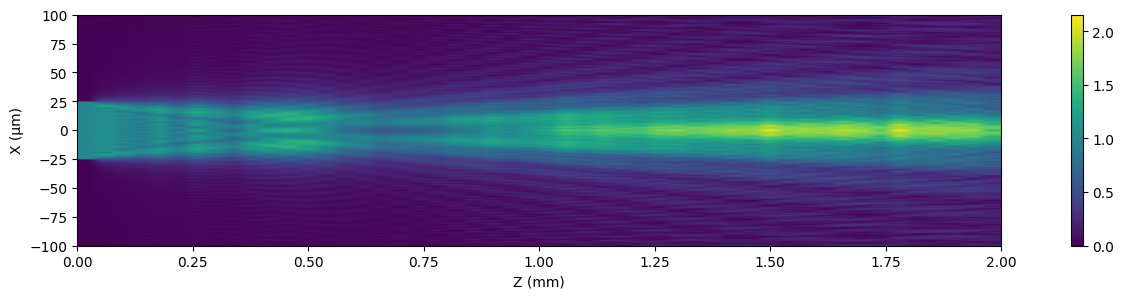

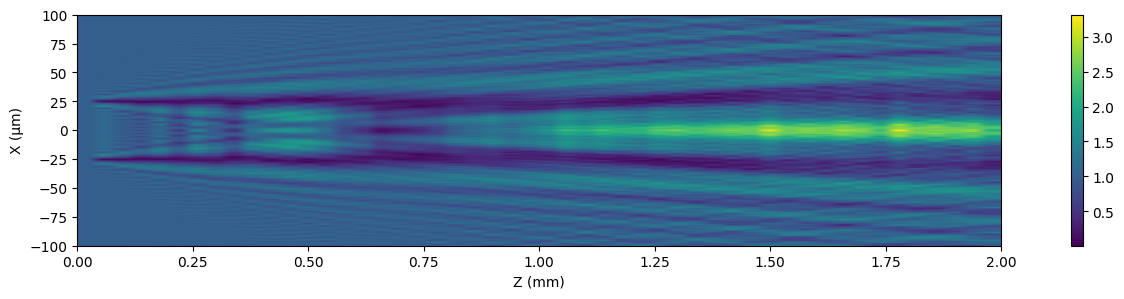

In [22]:
# - No modification necessary - 

square_aperture = generate_square_aperture(d_field, d_aperture, dx)
square_aperture_propagation_cutplane = propagation_cutplane(square_aperture, wvl, dx, z_range)

plt.figure(figsize=(18, 3)) 
plt.imshow(square_aperture_propagation_cutplane, origin='lower', aspect=0.0025, extent=[0, 2, -100, 100])
plt.xlabel("Z (mm)")
plt.ylabel("X (µm)")
plt.colorbar()
plt.show()

square_phase_plate = generate_square_phase_plate(d_field, d_aperture, dx)
square_phase_plate_propagation_cutplane = propagation_cutplane(square_phase_plate, wvl, dx, z_range)

plt.figure(figsize=(18,3))
plt.imshow(square_phase_plate_propagation_cutplane, origin='lower', aspect=0.0025, extent=[0, 2, -100, 100])
plt.xlabel("Z (mm)")
plt.ylabel("X (µm)")
plt.colorbar()
plt.show()

### Discussion
TODO